# Policy-Frame-Titelannotation: LLM-Konsens und SemEval-Abgleich

Dieses Notebook erzeugt belastbare Titelannotationen für Artikel aus **SemEval 2023 Task 3**.

## Volltext vs. Titel Annotation
Die SemEval Daten wurden auf Volltexten annotiert. Unsere Annotationsstudie hat ergeben, dass Frames auf Titel-Ebene grundsätzlich mit guter bis sehr guter Precision erkannt werden können.

Gleichzeitig sprechen die weniger guten Recall-Werte jedoch dafür, dass nicht alle Frames aus der Volltextannotation auch auf Titelebene erkannt werden können. Um nicht mit unnötigen Noise durch nur im Volltext erkannbare Frames zu trainieren, sollen insofern Titel- von Volltext-Frames getrennt werden.

Hierzu liefert die Annotationsstudie einen weiteren Ansatzpunkt. Alle LLMs zeigten in der Annotation bessere Werte für das Inter Rater Agreement sowie die Frame-Erkennung.

Vor diesem Hintergrund erfolgt die Titel-Annotation auf Basis eines LLM Konsens, der zusätzlich mit der SemEval Volltext-Annotation abgeglichen wird.

### Schritt 1 Unabhängige Annotation durch LLMs
Die Annotation durch LLMs erfolgt im single-Shot verfahren außerhalb dieses Skripts. Die Annotationsdateien werden in diesem Skript geladen.

### Schritt 2 Prüfen des LLM Konsens
Von den LLMs annotierte Frames werden nur bei mehreitlicher Übereinstimmung übernommen. Das Notebook erzeugt eine Konsensdatei sowie ein Konsensprotokoll, in dem für jeden Artikel festgehalten wird, mit welcher Übereinstimmung die LLMs welche frames erkannt haben.

### Schritt 3 Abgleich mit den SemEval Volltext Annotationen
Die Konsensdatei wird mit der Ground-Truth Datei (SemEval Volltext Annotationen) abgeglichen. Frames, die von LLMs im Konsens annotiert wurden, in der SemEval Volltext-Annotation jedoch nicht vorkommen, werden gestrichen. Das Notebook erstellt eine abschließende Titel-Annotations-Datei sowie ein Streichungsprotokoll.

### Schritt 4 Frames Statistik
Schließlich wird ausgewertet, welche Frames besonders häufig im Titel erkannt werden (LLM annotation) und welche Frames besonders häufig in den Volltexten (SemEval Annotation) vorkommen.

## Eingabedaten
Das erwartete breite Eingabeformat enthält eine eindeutige Artikel-ID (`Filename`), optionale Metadaten (`Headline_GER`, `Language`) und je eine Spalte pro Policy Frame.

**Umcodierung:** Die Eingabedaten enthalten die Werte `0` (Frame nicht einschlägig), `1` (Frame einschlägig) und `2` (Mainframe). Jeder Wert `2` wird unmittelbar nach der Validierung zu `1` umcodiert. Konsens, Protokolle und Ergebnisdateien arbeiten anschließend ausschließlich mit binären Frame-Werten (`0/1`).

In [1]:
# Standardbibliotheken und in Google Colab vorinstallierte Pakete
from pathlib import Path
from collections import Counter
import json
import math
import re
import shutil
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

print("Pandas:", pd.__version__)

Pandas: 2.2.2


## 1. Konfiguration

Die vier LLM-Dateien und die Ground-Truth-Datei müssen bereits im internen Colab-Ordner `/content` liegen. Hier werden nur ihre Dateinamen eingetragen. Es gibt keine Upload-Dialoge im Notebook.

In [2]:
# ---------- Eingaben ----------
CONTENT_DIR = Path("/content")
LLM_FILES = [
    "headlines_dataset_full_LLM_annotiert_claude_Sonnet5.xlsx",
    "headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.xlsx",
    "headlines_dataset_full_LLM_annotiert_ChatGPTPlus_5.6Sol.xlsx",
    "headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.xlsx",  # Dateinamen anpassen
]
GROUND_TRUTH_FILE = "ground_truth_full.xlsx"

# Tabellenblatt: 0 = erstes Blatt; alternativ Blattname als Text
LLM_SHEET = 0
GROUND_TRUTH_SHEET = 0

# ---------- Schema ----------
# Die LLM-Dateien und die Ground Truth dürfen unterschiedliche ID-Spaltennamen haben.
# Intern und in den Ausgaben wird einheitlich "article id" verwendet.
LLM_ID_COLUMN = "Filename"
GROUND_TRUTH_ID_COLUMN = "article id"
ID_COLUMN = "article id"
TITLE_COLUMN = "Headline_GER"
METADATA_COLUMNS = [TITLE_COLUMN, "Language"]

POLICY_FRAME_COLUMNS = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation",
]

# Bei abweichenden Frame-Namen hier eine eigene Liste einsetzen.
# Mit None werden gemeinsame 0/1/2-Spalten automatisch erkannt.
FRAME_COLUMNS = POLICY_FRAME_COLUMNS

# ---------- Codierung und Regeln ----------
# In allen Frame-Spalten wird 2 vor der Analyse zu 1 umcodiert.
VALUE_RECODE_MAP = {2: 1}

LLM_POSITIVE_VALUES = {1}
LLM_VALID_VALUES = {0, 1, 2}
GROUND_TRUTH_POSITIVE_VALUES = {1}
GROUND_TRUTH_VALID_VALUES = {0, 1, 2}

REQUIRED_LLM_FILES = 4
MIN_CONSENSUS_VOTES = 3
ACCEPTED_VOTE_COUNTS = set(range(MIN_CONSENSUS_VOTES, REQUIRED_LLM_FILES + 1))

# True verhindert, dass Artikel durch uneinheitliche IDs unbemerkt verloren gehen.
STRICT_LLM_ARTICLE_SET = True
# True verlangt für jeden LLM-annotierten Artikel eine SemEval-Zeile.
STRICT_GROUND_TRUTH_COVERAGE = True

# ---------- Ausgabe ----------
OUTPUT_DIR = Path("/content/titel_annotation_outputs")
AUTO_DOWNLOAD_ZIP = True

print("Konfiguration geladen.")

Konfiguration geladen.


## 2. Validierung und Verarbeitung

Die Verarbeitung liest die konfigurierten Dateien direkt aus `/content` ein. Sie bricht bei fehlenden Dateien, doppelten IDs, unbekannten Codes oder fehlenden Pflichtspalten bewusst ab. Dadurch werden stille Zuordnungsfehler vermieden.

In [3]:
def resolve_content_path(filename):
    path = Path(filename)
    return path if path.is_absolute() else CONTENT_DIR / path


def read_table(path, sheet=0):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix in {".xlsx", ".xls", ".xlsm"}:
        return pd.read_excel(path, sheet_name=sheet)
    if suffix == ".csv":
        return pd.read_csv(path, sep=None, engine="python")
    if suffix == ".tsv":
        return pd.read_csv(path, sep="\t")
    raise ValueError(f"Nicht unterstütztes Dateiformat: {path.name}")


if len(LLM_FILES) != REQUIRED_LLM_FILES:
    raise ValueError(
        f"Für einen 3/4- bzw. 4/4-Konsens werden genau {REQUIRED_LLM_FILES} "
        f"LLM-Dateien benötigt; eingetragen: {len(LLM_FILES)}"
    )

llm_paths = [resolve_content_path(filename) for filename in LLM_FILES]
ground_truth_path = resolve_content_path(GROUND_TRUTH_FILE)
missing = [str(path) for path in [*llm_paths, ground_truth_path] if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Diese Dateien fehlen im /content-Pfad: " + ", ".join(missing)
    )

print("Eingabedateien aus /content:")
for path in llm_paths:
    print(" - LLM:", path)
print(" - Ground Truth:", ground_truth_path)


def normalized_code(value):
    # Vereinheitlicht Zahlen- und Textcodes für robuste Vergleiche.
    if pd.isna(value):
        return None
    if isinstance(value, (bool, np.bool_)):
        return "1" if bool(value) else "0"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        return str(int(value))
    return unicodedata.normalize("NFKC", str(value)).strip().casefold()


def normalized_set(values):
    return {normalized_code(v) for v in values}


def positive_mask(series, positive_values):
    positive = normalized_set(positive_values)
    return series.map(normalized_code).isin(positive)


def recode_frame_values(df, frame_columns, recode_map):
    # Codiert konfigurierte Werte in allen Frame-Spalten um (hier: 2 -> 1).
    normalized_map = {normalized_code(k): v for k, v in recode_map.items()}
    result = df.copy()
    for frame in frame_columns:
        result[frame] = result[frame].map(
            lambda value: normalized_map.get(normalized_code(value), value)
            if not pd.isna(value) else value
        )
    return result


def normalized_column_name(value):
    # Ignoriert Groß-/Kleinschreibung und Satzzeichen, nicht aber Wörter.
    text = unicodedata.normalize("NFKC", str(value)).casefold().strip()
    return " ".join(re.findall(r"\w+", text, flags=re.UNICODE))


def resolve_column_name(columns, requested, source_name):
    if requested in columns:
        return requested
    key = normalized_column_name(requested)
    matches = [col for col in columns if normalized_column_name(col) == key]
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise ValueError(
            f"{source_name}: Spalte '{requested}' ist nicht eindeutig zuordenbar: {matches}"
        )
    return None


schema_resolution_records = []


def validate_and_prepare(
    df, source_name, source_id_column, frame_columns, valid_values
):
    df = df.copy()
    rename_map = {}

    resolved_id = resolve_column_name(df.columns, source_id_column, source_name)
    if resolved_id is None:
        raise ValueError(
            f"{source_name}: ID-Spalte '{source_id_column}' fehlt. "
            f"Vorhandene Spalten: {list(df.columns)}"
        )
    rename_map[resolved_id] = ID_COLUMN
    schema_resolution_records.append({
        "Datei": source_name,
        "Typ": "ID",
        "Quellspalte": resolved_id,
        "Interne_Spalte": ID_COLUMN,
    })

    missing = []
    for frame in frame_columns:
        resolved_frame = resolve_column_name(df.columns, frame, source_name)
        if resolved_frame is None:
            missing.append(frame)
        else:
            rename_map[resolved_frame] = frame
            schema_resolution_records.append({
                "Datei": source_name,
                "Typ": "Frame",
                "Quellspalte": resolved_frame,
                "Interne_Spalte": frame,
            })
    if missing:
        raise ValueError(
            f"{source_name}: Frame-Spalten fehlen oder konnten nicht zugeordnet werden: {missing}"
        )

    df = df.rename(columns=rename_map)

    if df[ID_COLUMN].isna().any():
        rows = (df.index[df[ID_COLUMN].isna()] + 2).tolist()[:10]
        raise ValueError(f"{source_name}: leere Artikel-ID in Excel-Zeile(n) {rows}")

    df[ID_COLUMN] = df[ID_COLUMN].astype(str).str.strip()
    duplicates = df.loc[df[ID_COLUMN].duplicated(keep=False), ID_COLUMN].unique().tolist()
    if duplicates:
        raise ValueError(f"{source_name}: doppelte Artikel-IDs, z. B. {duplicates[:10]}")

    allowed = normalized_set(valid_values)
    invalid_report = {}
    for frame in frame_columns:
        observed = {normalized_code(v) for v in df[frame].dropna().unique()}
        invalid = sorted(v for v in observed if v not in allowed)
        if invalid:
            invalid_report[frame] = invalid[:10]
    if invalid_report:
        raise ValueError(
            f"{source_name}: unbekannte Frame-Codes. "
            f"Gültige Codes sind {sorted(allowed)}. Details: {invalid_report}"
        )
    return recode_frame_values(df, frame_columns, VALUE_RECODE_MAP)


def auto_detect_frames(llm_frames):
    common = set(llm_frames[0].columns)
    for df in llm_frames[1:]:
        common &= set(df.columns)
    excluded = {ID_COLUMN, LLM_ID_COLUMN, GROUND_TRUTH_ID_COLUMN, *METADATA_COLUMNS}
    allowed = normalized_set(LLM_VALID_VALUES)
    detected = []
    # Reihenfolge der ersten LLM-Datei beibehalten
    for col in llm_frames[0].columns:
        if col in excluded or col not in common:
            continue
        ok = True
        for df in llm_frames:
            observed = {normalized_code(v) for v in df[col].dropna().unique()}
            if not observed.issubset(allowed):
                ok = False
                break
        if ok:
            detected.append(col)
    if not detected:
        raise ValueError("Es konnten keine gemeinsamen Frame-Spalten erkannt werden.")
    return detected


llm_raw = [read_table(path, LLM_SHEET) for path in llm_paths]
ground_truth_raw = read_table(ground_truth_path, GROUND_TRUTH_SHEET)

frame_columns = list(FRAME_COLUMNS) if FRAME_COLUMNS is not None else auto_detect_frames(llm_raw)
llm_data = [
    validate_and_prepare(
        df, path.name, LLM_ID_COLUMN, frame_columns, LLM_VALID_VALUES
    )
    for df, path in zip(llm_raw, llm_paths)
]
ground_truth = validate_and_prepare(
    ground_truth_raw,
    ground_truth_path.name,
    GROUND_TRUTH_ID_COLUMN,
    frame_columns,
    GROUND_TRUTH_VALID_VALUES,
)

if TITLE_COLUMN not in llm_data[0].columns:
    raise ValueError(
        f"{llm_paths[0].name}: Titelspalte '{TITLE_COLUMN}' fehlt. "
        "Sie wird für die Ausgabedateien benötigt."
    )

schema_resolution = pd.DataFrame(schema_resolution_records)

print(f"Erkannte/verwendete Frames: {len(frame_columns)}")
print(f"ID-Abgleich: LLM '{LLM_ID_COLUMN}' <-> Ground Truth '{GROUND_TRUTH_ID_COLUMN}'")
display(pd.DataFrame({"Frame": frame_columns}))

Eingabedateien aus /content:
 - LLM: /content/headlines_dataset_full_LLM_annotiert_claude_Sonnet5.xlsx
 - LLM: /content/headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.xlsx
 - LLM: /content/headlines_dataset_full_LLM_annotiert_ChatGPTPlus_5.6Sol.xlsx
 - LLM: /content/headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.xlsx
 - Ground Truth: /content/ground_truth_full.xlsx
Erkannte/verwendete Frames: 14
ID-Abgleich: LLM 'Filename' <-> Ground Truth 'article id'


,Frame
0,Economic
1,Capacity and resources
2,Morality
3,Fairness and equality
4,"Legality, constitutionality and jurisprudence"
5,Policy prescription and evaluation
6,Crime and punishment
7,Security and defense
8,Health and safety
9,Quality of life


## 3. LLM-Konsens berechnen

Die LLM-Dateien werden über `Filename`, die Ground Truth über `article id` identifiziert. Beide Spalten werden intern auf dieselbe Artikel-ID vereinheitlicht. Die Zeilenposition spielt keine Rolle. Fehlende oder zusätzliche IDs werden im Prüfbericht sichtbar; in der strikten Standardeinstellung führen sie zum Abbruch.

In [4]:
llm_names = []
used_names = Counter()
for i, path in enumerate(llm_paths, start=1):
    base = re.sub(r"[^0-9A-Za-zÄÖÜäöüß_-]+", "_", path.stem).strip("_") or f"LLM_{i}"
    used_names[base] += 1
    llm_names.append(base if used_names[base] == 1 else f"{base}_{used_names[base]}")

id_lists = [df[ID_COLUMN].tolist() for df in llm_data]
id_sets = [set(ids) for ids in id_lists]
reference_ids = id_lists[0]
common_ids = set.intersection(*id_sets)
union_ids = set.union(*id_sets)

article_set_report = pd.DataFrame({
    "Datei": [p.name for p in llm_paths],
    "Artikel": [len(s) for s in id_sets],
    "Fehlen_gegenüber_Union": [len(union_ids - s) for s in id_sets],
    "Zusätzlich_gegenüber_Schnittmenge": [len(s - common_ids) for s in id_sets],
})

if STRICT_LLM_ARTICLE_SET and any(s != id_sets[0] for s in id_sets[1:]):
    examples = {
        llm_paths[i].name: sorted(list(union_ids - id_sets[i]))[:10]
        for i in range(len(id_sets))
        if union_ids - id_sets[i]
    }
    raise ValueError(
        "Die LLM-Dateien enthalten nicht dieselben Artikel-IDs. "
        f"Beispiele fehlender IDs: {examples}. "
        "Fehler beheben oder STRICT_LLM_ARTICLE_SET=False setzen."
    )

# Bei nicht-strikter Verarbeitung wird transparent nur die Schnittmenge genutzt.
article_ids = [article_id for article_id in reference_ids if article_id in common_ids]
if not article_ids:
    raise ValueError("Die LLM-Dateien haben keine gemeinsamen Artikel-IDs.")

llm_indexed = [df.set_index(ID_COLUMN).loc[article_ids] for df in llm_data]

# Metadaten und insbesondere der Titel stammen aus der ersten LLM-Datei.
available_metadata = [c for c in METADATA_COLUMNS if c in llm_indexed[0].columns]
base_data = llm_indexed[0][available_metadata].copy() if available_metadata else pd.DataFrame(index=article_ids)
base_data.index.name = ID_COLUMN
title_lookup = base_data[TITLE_COLUMN].to_dict()

metadata_mismatch_records = []
for metadata_col in available_metadata:
    ref = llm_indexed[0][metadata_col].fillna("").astype(str)
    for model_idx in range(1, len(llm_indexed)):
        if metadata_col not in llm_indexed[model_idx].columns:
            continue
        other = llm_indexed[model_idx][metadata_col].fillna("").astype(str)
        mismatch = ref.ne(other)
        for article_id in mismatch[mismatch].index[:100]:
            metadata_mismatch_records.append({
                ID_COLUMN: article_id,
                "Spalte": metadata_col,
                "Referenzdatei": llm_paths[0].name,
                "Vergleichsdatei": llm_paths[model_idx].name,
                "Referenzwert": ref.loc[article_id],
                "Vergleichswert": other.loc[article_id],
            })
metadata_mismatches = pd.DataFrame(metadata_mismatch_records)

vote_counts = pd.DataFrame(index=article_ids)
consensus_binary = pd.DataFrame(index=article_ids)
protocol_records = []

for frame in frame_columns:
    raw_series = [df[frame] for df in llm_indexed]
    positive_series = [positive_mask(s, LLM_POSITIVE_VALUES) for s in raw_series]
    votes = sum(s.astype(int) for s in positive_series)
    accepted = votes.isin(ACCEPTED_VOTE_COUNTS)
    vote_counts[frame] = votes.astype(int)
    consensus_binary[frame] = accepted.astype(int)

    for pos, article_id in enumerate(article_ids):
        vote_count = int(votes.iloc[pos])
        row = {
            ID_COLUMN: article_id,
            TITLE_COLUMN: title_lookup.get(article_id, ""),
            "Frame": frame,
            "Positive_Stimmen": vote_count,
            "Übereinstimmung": f"{vote_count}/{REQUIRED_LLM_FILES}",
            "Konsens_übernommen": int(vote_count in ACCEPTED_VOTE_COUNTS),
            "Konsensstatus": (
                f"übernommen ({vote_count}/{REQUIRED_LLM_FILES})"
                if vote_count in ACCEPTED_VOTE_COUNTS
                else f"nicht übernommen ({vote_count}/{REQUIRED_LLM_FILES})"
            ),
        }
        for model_name, raw, pos_mask in zip(llm_names, raw_series, positive_series):
            row[f"Binärwert_{model_name}"] = raw.iloc[pos]
            row[f"Positiv_{model_name}"] = int(pos_mask.iloc[pos])
        protocol_records.append(row)

consensus_protocol = pd.DataFrame(protocol_records)
consensus_wide = base_data.join(consensus_binary).reset_index()
consensus_positive_long = consensus_protocol.loc[
    consensus_protocol["Konsens_übernommen"].eq(1)
].copy()

print(f"Verarbeitete Artikel: {len(article_ids):,}".replace(",", "."))
print("Positive Artikel-Frame-Paare im LLM-Konsens:", int(consensus_binary.to_numpy().sum()))
display(article_set_report)
display(consensus_positive_long.head(10))

Verarbeitete Artikel: 1.401
Positive Artikel-Frame-Paare im LLM-Konsens: 1308


,Datei,Artikel,Fehlen_gegenüber_Union,Zusätzlich_gegenüber_Schnittmenge
0,headlines_dataset_full_LLM_annotiert_claude_Sonnet5.xlsx,1401,0,0
1,headlines_dataset_full_LLM_annotiert_ChatGPT_5.6Luna.xlsx,1401,0,0
2,headlines_dataset_full_LLM_annotiert_ChatGPTPlus_5.6Sol.xlsx,1401,0,0
3,headlines_dataset_full_LLM_annotiert_Gemini_Flash3.6.xlsx,1401,0,0


,article id,Headline_GER,Frame,Positive_Stimmen,Übereinstimmung,Konsens_übernommen,Konsensstatus,Binärwert_headlines_dataset_full_LLM_annotiert_claude_Sonnet5,Positiv_headlines_dataset_full_LLM_annotiert_claude_Sonnet5,Binärwert_headlines_dataset_full_LLM_annotiert_ChatGPT_5_6Luna,Positiv_headlines_dataset_full_LLM_annotiert_ChatGPT_5_6Luna,Binärwert_headlines_dataset_full_LLM_annotiert_ChatGPTPlus_5_6Sol,Positiv_headlines_dataset_full_LLM_annotiert_ChatGPTPlus_5_6Sol,Binärwert_headlines_dataset_full_LLM_annotiert_Gemini_Flash3_6,Positiv_headlines_dataset_full_LLM_annotiert_Gemini_Flash3_6
0,article813452859.txt,"EU profitiert vom Handel mit Großbritannien, während London Geld verliert – politischer Aktivist",Economic,4,4/4,1,übernommen (4/4),1,1,1,1,1,1,1,1
12,article813992175.txt,Schrecklicher Brexit-Deal: Alle EU-Staaten könnten Großbritannien um Handelszugeständnisse bitten - Prof,Economic,4,4/4,1,übernommen (4/4),1,1,1,1,1,1,1,1
29,article817408115.txt,Die EU liebt britisches Geld mehr als die Demokratie,Economic,4,4/4,1,übernommen (4/4),1,1,1,1,1,1,1,1
147,article707451080.txt,Das Repräsentantenhaus zahlte 15.000.000 US-Dollar an Opfer sexueller Belästigung,Economic,4,4/4,1,übernommen (4/4),1,1,1,1,1,1,1,1
153,article709732928.txt,"Uranium One Bombshell: Beweise für Bestechung, Erpressung, Schmiergelder, Geldwäsche und mehr!",Economic,3,3/4,1,übernommen (3/4),1,1,1,1,0,0,1,1
211,article729670169.txt,Puerto Rico soll 16 Milliarden US-Dollar an staatlicher Katastrophenhilfe erhalten,Economic,4,4/4,1,übernommen (4/4),1,1,1,1,1,1,1,1
288,article758512204.txt,"Zeuge: Der IT-Berater der muslimischen Demokraten, Awan, hat sie abgehört, dann wurde das von ihr kontrollierte Bank...",Economic,3,3/4,1,übernommen (3/4),1,1,0,0,1,1,1,1
306,article761968851.txt,"Nationale Daten | Jobs im Dezember – TRUMP-EFFEKT! Die Vertreibung amerikanischer Arbeitnehmer, die Einwandererbevöl...",Economic,3,3/4,1,übernommen (3/4),0,0,1,1,1,1,1,1
311,article762160164.txt,"Obama versuchte heimlich, Banken dazu zu bringen, dem Iran zu helfen, doch die Banken weigerten sich",Economic,3,3/4,1,übernommen (3/4),1,1,0,0,1,1,1,1
404,article786527921.txt,"„Stille Spende“: Unternehmens-E-Mails enthüllen, dass Google-Führungskräfte versucht haben, Latino-Wähler zu gewinne...",Economic,4,4/4,1,übernommen (4/4),1,1,1,1,1,1,1,1


## 4. Abgleich mit der SemEval-Volltextannotation

Ein LLM-Konsens-Frame wird nur dann als Titelannotation behalten, wenn derselbe Frame in der SemEval-Zeile des Artikels positiv codiert ist.

In [5]:
gt_indexed_all = ground_truth.set_index(ID_COLUMN)
gt_ids = set(gt_indexed_all.index)
missing_in_gt = [article_id for article_id in article_ids if article_id not in gt_ids]

if STRICT_GROUND_TRUTH_COVERAGE and missing_in_gt:
    raise ValueError(
        f"Für {len(missing_in_gt)} LLM-annotierte Artikel fehlt die SemEval-Ground-Truth, "
        f"z. B. {missing_in_gt[:10]}."
    )

# Fehlende Ground-Truth-Zeilen werden nur im nicht-strikten Modus als nicht positiv behandelt.
gt_indexed = gt_indexed_all.reindex(article_ids)
gt_binary = pd.DataFrame(index=article_ids)
for frame in frame_columns:
    gt_binary[frame] = positive_mask(gt_indexed[frame], GROUND_TRUTH_POSITIVE_VALUES).astype(int)

final_binary = (consensus_binary.astype(bool) & gt_binary.astype(bool)).astype(int)
removed_binary = (consensus_binary.astype(bool) & ~gt_binary.astype(bool)).astype(int)
final_wide = base_data.join(final_binary).reset_index()

final_long_records = []
removal_records = []
protocol_lookup = consensus_protocol.set_index([ID_COLUMN, "Frame"])
for frame in frame_columns:
    for article_id in article_ids:
        if final_binary.at[article_id, frame] == 1:
            final_long_records.append({
                ID_COLUMN: article_id,
                TITLE_COLUMN: title_lookup.get(article_id, ""),
                "Frame": frame,
                "Titelannotation": 1,
            })
        if removed_binary.at[article_id, frame] == 1:
            protocol_row = protocol_lookup.loc[(article_id, frame)]
            record = {
                ID_COLUMN: article_id,
                TITLE_COLUMN: title_lookup.get(article_id, ""),
                "Frame": frame,
                "Positive_Stimmen": int(protocol_row["Positive_Stimmen"]),
                "Übereinstimmung": protocol_row["Übereinstimmung"],
                "SemEval_Binärwert": gt_indexed.at[article_id, frame] if article_id in gt_ids else np.nan,
                "Grund": (
                    "Artikel fehlt in der SemEval-Datei"
                    if article_id not in gt_ids
                    else "LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation"
                ),
            }
            for model_name in llm_names:
                record[f"Binärwert_{model_name}"] = protocol_row[f"Binärwert_{model_name}"]
            removal_records.append(record)

final_long = pd.DataFrame(
    final_long_records, columns=[ID_COLUMN, TITLE_COLUMN, "Frame", "Titelannotation"]
)
removal_protocol = pd.DataFrame(
    removal_records,
    columns=[
        ID_COLUMN, TITLE_COLUMN, "Frame", "Positive_Stimmen", "Übereinstimmung", "SemEval_Binärwert",
        "Grund", *[f"Binärwert_{name}" for name in llm_names]
    ],
)

print("Nach SemEval-Abgleich verbliebene Artikel-Frame-Paare:", int(final_binary.to_numpy().sum()))
print("Gestrichene Artikel-Frame-Paare:", int(removed_binary.to_numpy().sum()))
display(removal_protocol.head(10))

Nach SemEval-Abgleich verbliebene Artikel-Frame-Paare: 1006
Gestrichene Artikel-Frame-Paare: 302


,article id,Headline_GER,Frame,Positive_Stimmen,Übereinstimmung,SemEval_Binärwert,Grund,Binärwert_headlines_dataset_full_LLM_annotiert_claude_Sonnet5,Binärwert_headlines_dataset_full_LLM_annotiert_ChatGPT_5_6Luna,Binärwert_headlines_dataset_full_LLM_annotiert_ChatGPTPlus_5_6Sol,Binärwert_headlines_dataset_full_LLM_annotiert_Gemini_Flash3_6
0,article707451080.txt,Das Repräsentantenhaus zahlte 15.000.000 US-Dollar an Opfer sexueller Belästigung,Economic,4,4/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,1,1,1
1,article709732928.txt,"Uranium One Bombshell: Beweise für Bestechung, Erpressung, Schmiergelder, Geldwäsche und mehr!",Economic,3,3/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,1,0,1
2,article758512204.txt,"Zeuge: Der IT-Berater der muslimischen Demokraten, Awan, hat sie abgehört, dann wurde das von ihr kontrollierte Bank...",Economic,3,3/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,0,1,1
3,article786527921.txt,"„Stille Spende“: Unternehmens-E-Mails enthüllen, dass Google-Führungskräfte versucht haben, Latino-Wähler zu gewinne...",Economic,4,4/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,1,1,1
4,article787759779.txt,"Der Anwalt des Kavanaugh-Anklägers ist stellvertretender Vorsitzender der von Soros finanzierten Organisation, die s...",Economic,3,3/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,1,1,0
5,article999000849.txt,"Von Soros finanzierte Anwälte helfen Wohnwagenmigranten, in den Vereinigten Staaten Asyl zu bekommen",Economic,3,3/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,1,1,0
6,article23131.txt,Macron von Algerien finanziert?,Economic,4,4/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,1,1,1
7,article23120.txt,"Flüchtlinge: Frankreich gewinnt sein Willkommensgefühl zurück, dauerhafte Wende oder Fata Morgana?",Economic,3,3/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,1,1,0
8,article23169.txt,Abschaffung der TV-Gebühr: Versprechen gehalten....,Economic,3,3/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,1,0,1
9,article22198.txt,"Chaos an Flughäfen immer schlimmer: Pilot im Frachtraum eingesperrt, während Rollkoffer Maschine nach Mallorca steuerte",Economic,3,3/4,0,"LLM-Konsens vorhanden, Frame fehlt in der SemEval-Volltextannotation",1,0,1,1


## 5. Frame-Statistik

Verglichen werden LLM-Konsens auf Titelebene, SemEval-Volltextannotation und die finale Titelannotation. Zusätzlich werden 3/4- und 4/4-Konsens sowie die Häufigkeiten je einzelnem LLM ausgewiesen.

,Frame,LLM_Konsens_Titel_n,LLM_Konsens_Titel_%,davon_3_von_4_n,davon_4_von_4_n,SemEval_Volltext_n,SemEval_Volltext_%,Finale_Titelannotation_n,Finale_Titelannotation_%,Gestrichen_n,Beibehaltungsquote_%,Titelsichtbarkeit_vs_SemEval_%,Anteil_an_finalen_Annotationen_%
0,Political,372,0.265525,140,232,765,0.546039,291,0.207709,81,0.782258,0.380392,0.289264
1,Security and defense,202,0.144183,76,126,585,0.417559,154,0.109921,48,0.762376,0.263248,0.153082
2,Health and safety,113,0.080657,63,50,375,0.267666,102,0.072805,11,0.902655,0.272000,0.101392
3,"Legality, constitutionality and jurisprudence",110,0.078515,62,48,444,0.316916,82,0.058530,28,0.745455,0.184685,0.081511
4,Morality,108,0.077088,72,36,399,0.284797,89,0.063526,19,0.824074,0.223058,0.088469
5,External regulation and reputation,104,0.074233,66,38,514,0.366881,74,0.052819,30,0.711538,0.143969,0.073559
6,Crime and punishment,103,0.073519,49,54,401,0.286224,90,0.064240,13,0.873786,0.224439,0.089463
7,Economic,78,0.055675,44,34,431,0.307637,59,0.042113,19,0.756410,0.136891,0.058648
8,Policy prescription and evaluation,55,0.039258,46,9,409,0.291934,28,0.019986,27,0.509091,0.068460,0.027833
9,Public opinion,26,0.018558,17,9,202,0.144183,15,0.010707,11,0.576923,0.074257,0.014911


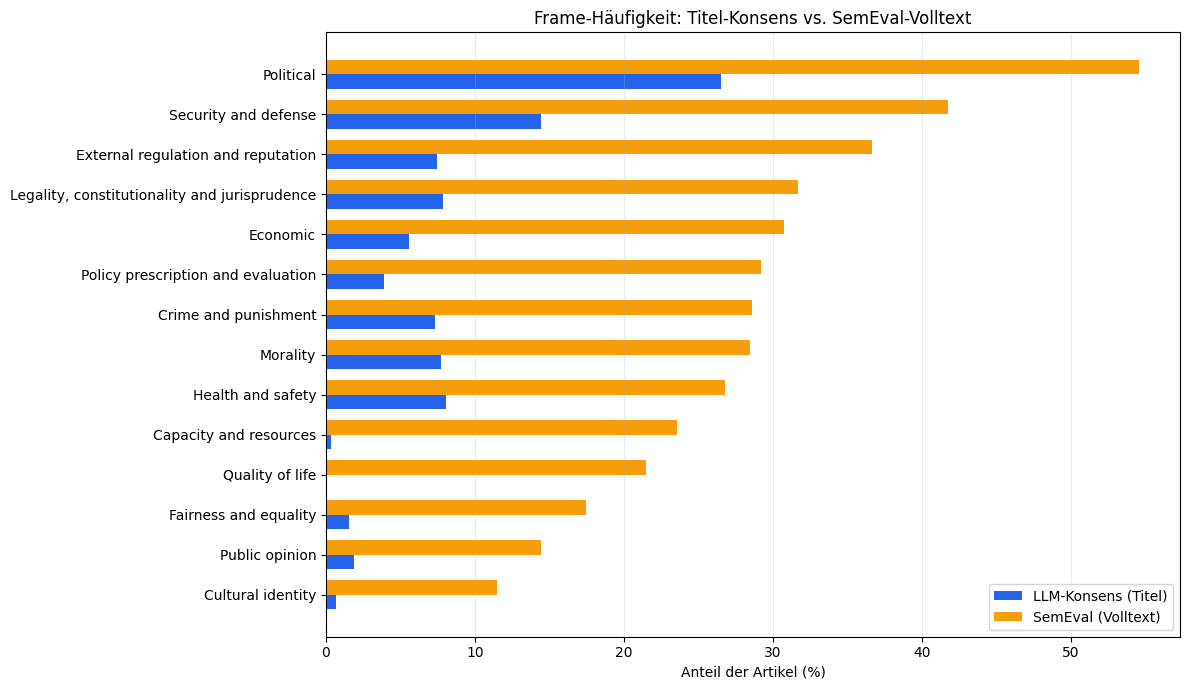

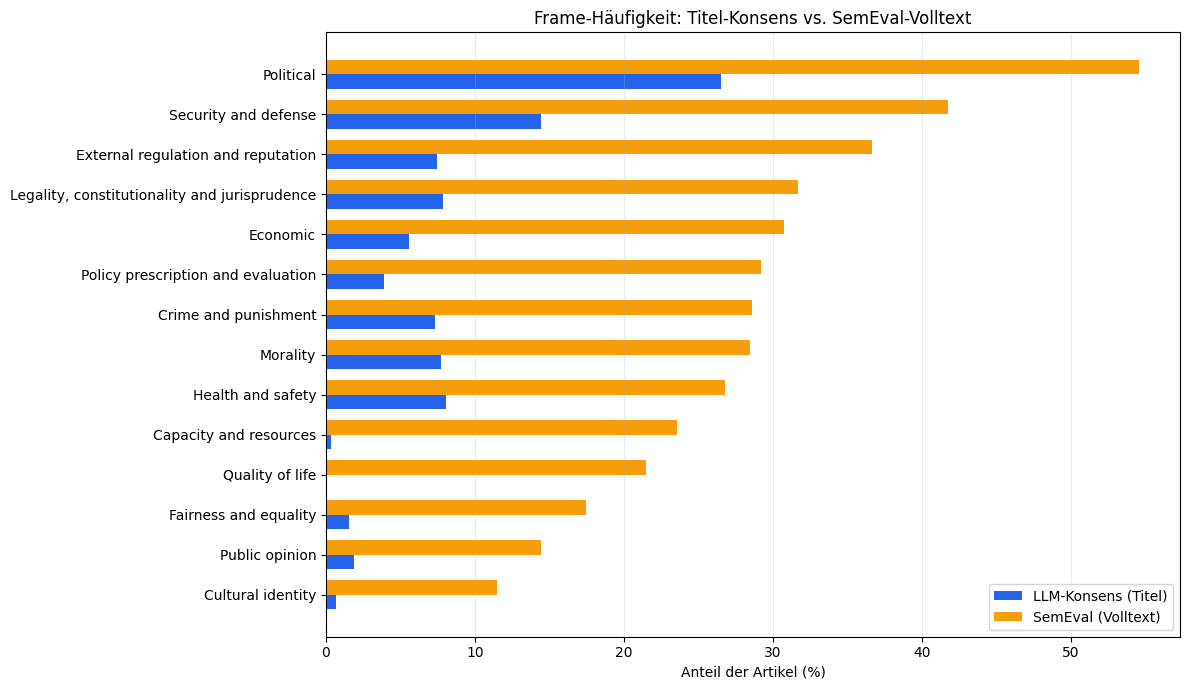

In [6]:
n_articles = len(article_ids)
total_final_annotations = int(final_binary.to_numpy().sum())
stats_records = []
for frame in frame_columns:
    title_count = int(consensus_binary[frame].sum())
    fulltext_count = int(gt_binary[frame].sum())
    final_count = int(final_binary[frame].sum())
    removed_count = int(removed_binary[frame].sum())
    record = {
        "Frame": frame,
        "LLM_Konsens_Titel_n": title_count,
        "LLM_Konsens_Titel_%": title_count / n_articles if n_articles else np.nan,
    }
    for vote_count in sorted(ACCEPTED_VOTE_COUNTS):
        record[f"davon_{vote_count}_von_{REQUIRED_LLM_FILES}_n"] = int(
            vote_counts[frame].eq(vote_count).sum()
        )
    record.update({
        "SemEval_Volltext_n": fulltext_count,
        "SemEval_Volltext_%": fulltext_count / n_articles if n_articles else np.nan,
        "Finale_Titelannotation_n": final_count,
        "Finale_Titelannotation_%": final_count / n_articles if n_articles else np.nan,
        "Gestrichen_n": removed_count,
        "Beibehaltungsquote_%": final_count / title_count if title_count else np.nan,
        "Titelsichtbarkeit_vs_SemEval_%": final_count / fulltext_count if fulltext_count else np.nan,
        "Anteil_an_finalen_Annotationen_%": (
            final_count / total_final_annotations if total_final_annotations else np.nan
        ),
    })
    stats_records.append(record)

frame_statistics = pd.DataFrame(stats_records).sort_values(
    ["LLM_Konsens_Titel_n", "SemEval_Volltext_n"], ascending=False
).reset_index(drop=True)

per_llm_records = []
for model_name, indexed_df in zip(llm_names, llm_indexed):
    for frame in frame_columns:
        count = int(positive_mask(indexed_df[frame], LLM_POSITIVE_VALUES).sum())
        per_llm_records.append({
            "LLM": model_name,
            "Frame": frame,
            "Positiv_n": count,
            "Positiv_%": count / n_articles if n_articles else np.nan,
        })
per_llm_statistics = pd.DataFrame(per_llm_records)

display(frame_statistics)

plot_data = frame_statistics.sort_values("SemEval_Volltext_%", ascending=True)
y = np.arange(len(plot_data))
height = 0.36
fig, ax = plt.subplots(figsize=(12, max(6, len(plot_data) * 0.5)))
ax.barh(y - height/2, plot_data["LLM_Konsens_Titel_%"] * 100, height,
        label="LLM-Konsens (Titel)", color="#2563EB")
ax.barh(y + height/2, plot_data["SemEval_Volltext_%"] * 100, height,
        label="SemEval (Volltext)", color="#F59E0B")
ax.set_yticks(y, plot_data["Frame"])
ax.set_xlabel("Anteil der Artikel (%)")
ax.set_title("Frame-Häufigkeit: Titel-Konsens vs. SemEval-Volltext")
ax.grid(axis="x", alpha=0.25)
ax.legend()
fig.tight_layout()
display(fig)

## 6. Dateien schreiben und herunterladen

Die Excel-Dateien werden mit `openpyxl` geschrieben; `xlsxwriter` wird nicht benötigt. Sie erhalten Filter, eingefrorene Kopfzeilen, lesbare Spaltenbreiten und Prozentformate. Zusätzlich wird ein ZIP mit allen Ergebnissen erstellt.

In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
chart_path = OUTPUT_DIR / "05_frame_statistik.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight")


def safe_excel_value(value):
    if isinstance(value, (list, tuple, set, dict)):
        return json.dumps(value, ensure_ascii=False)
    return value


from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as OpenpyxlImage


def write_formatted_workbook(path, sheets, percent_columns=None, image_sheet=None, image_path=None):
    percent_columns = percent_columns or {}
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, df in sheets.items():
            clean = df.copy()
            for col in clean.columns:
                if clean[col].dtype == "object":
                    clean[col] = clean[col].map(safe_excel_value)
            clean.to_excel(writer, sheet_name=sheet_name, index=False)
            ws = writer.sheets[sheet_name]
            ws.freeze_panes = "B2"
            ws.row_dimensions[1].height = 32

            header_fill = PatternFill("solid", fgColor="1F4E78")
            header_font = Font(bold=True, color="FFFFFF")
            header_alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            thin_side = Side(style="thin", color="D9E1F2")
            header_border = Border(left=thin_side, right=thin_side, top=thin_side, bottom=thin_side)

            if len(clean.columns) > 0:
                last_col = get_column_letter(len(clean.columns))
                last_row = max(len(clean) + 1, 1)
                ws.auto_filter.ref = f"A1:{last_col}{last_row}"
                for cell in ws[1]:
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = header_alignment
                    cell.border = header_border

            for col_idx, col in enumerate(clean.columns):
                sample = clean[col].dropna().astype(str).head(500)
                max_len = max([len(str(col)), *sample.map(len).tolist()] or [len(str(col))])
                width = min(max(max_len + 2, 10), 45)
                excel_col = get_column_letter(col_idx + 1)
                ws.column_dimensions[excel_col].width = width

                number_format = "0.0%" if col in percent_columns.get(sheet_name, []) else None
                if col.endswith("_n") or col in {"Positive_Stimmen", "Konsens_übernommen", "Titelannotation"}:
                    number_format = "0"
                if number_format is not None:
                    for row_idx in range(2, len(clean) + 2):
                        ws.cell(row=row_idx, column=col_idx + 1).number_format = number_format

            if image_path is not None and image_sheet == sheet_name:
                image = OpenpyxlImage(str(image_path))
                image.width = int(image.width * 0.62)
                image.height = int(image.height * 0.62)
                insert_col = min(len(clean.columns) + 3, 15)
                ws.add_image(image, f"{get_column_letter(insert_col)}2")


validation_summary = pd.DataFrame([
    {"Prüfung": "Anzahl LLM-Dateien", "Ergebnis": len(llm_paths), "Status": "OK"},
    {"Prüfung": "Verarbeitete Artikel", "Ergebnis": len(article_ids), "Status": "OK"},
    {"Prüfung": "Frame-Spalten", "Ergebnis": len(frame_columns), "Status": "OK"},
    {"Prüfung": "Titelspalte in Ausgabe", "Ergebnis": TITLE_COLUMN,
     "Status": "OK" if TITLE_COLUMN in base_data.columns else "Fehler"},
    {"Prüfung": "LLM-ID-Sets identisch", "Ergebnis": all(s == id_sets[0] for s in id_sets),
     "Status": "OK" if all(s == id_sets[0] for s in id_sets) else "Hinweis"},
    {"Prüfung": "Artikel ohne Ground Truth", "Ergebnis": len(missing_in_gt),
     "Status": "OK" if not missing_in_gt else "Hinweis"},
    {"Prüfung": "Metadaten-Abweichungen (max. 100 je Vergleich protokolliert)",
     "Ergebnis": len(metadata_mismatches), "Status": "OK" if metadata_mismatches.empty else "Hinweis"},
])

config_table = pd.DataFrame([
    {"Parameter": "LLM_ID_COLUMN", "Wert": LLM_ID_COLUMN},
    {"Parameter": "GROUND_TRUTH_ID_COLUMN", "Wert": GROUND_TRUTH_ID_COLUMN},
    {"Parameter": "ID_COLUMN_intern_und_Ausgabe", "Wert": ID_COLUMN},
    {"Parameter": "TITLE_COLUMN", "Wert": TITLE_COLUMN},
    {"Parameter": "FRAME_COLUMNS", "Wert": frame_columns},
    {"Parameter": "VALUE_RECODE_MAP", "Wert": VALUE_RECODE_MAP},
    {"Parameter": "LLM_POSITIVE_VALUES_nach_Umcodierung", "Wert": sorted(normalized_set(LLM_POSITIVE_VALUES))},
    {"Parameter": "GROUND_TRUTH_POSITIVE_VALUES", "Wert": sorted(normalized_set(GROUND_TRUTH_POSITIVE_VALUES))},
    {"Parameter": "ACCEPTED_VOTE_COUNTS", "Wert": sorted(ACCEPTED_VOTE_COUNTS)},
])

# ---------- Zentrale Textauswertung für die spätere Trainingsgrundlage ----------
def format_int(value):
    return f"{int(value):,}".replace(",", ".")


def format_pct(numerator, denominator):
    if not denominator:
        return "n. a."
    return f"{100 * numerator / denominator:.1f} %".replace(".", ",")


consensus_article_ids = set(
    consensus_binary.index[consensus_binary.sum(axis=1).gt(0)]
)
final_article_ids = set(
    final_binary.index[final_binary.sum(axis=1).gt(0)]
)
conflict_article_ids = set(removal_protocol[ID_COLUMN].dropna().astype(str))

n_total_articles = len(article_ids)
n_consensus_articles = len(consensus_article_ids)
n_conflict_articles = len(conflict_article_ids)
n_final_articles = len(final_article_ids)
n_no_consensus = n_total_articles - n_consensus_articles
n_no_final_frame = n_total_articles - n_final_articles
n_all_consensus_removed = len(consensus_article_ids - final_article_ids)
n_mixed_conflict = len(conflict_article_ids & final_article_ids)
n_all_consensus_match = len(consensus_article_ids - conflict_article_ids)
n_consensus_annotations = int(consensus_binary.to_numpy().sum())
n_removed_annotations = len(removal_protocol)
final_frames_per_article = final_binary.sum(axis=1).value_counts().sort_index()

report_lines = [
    "ZENTRALE AUSWERTUNG DER POLICY-FRAME-TITELANNOTATION",
    "=" * 62,
    "",
    "1. METHODISCHE GRUNDLAGE",
    f"Ausgewertete LLM-Dateien: {REQUIRED_LLM_FILES}",
    (
        "Konsensregel: Frame wird bei "
        + " oder ".join(f"{v}/{REQUIRED_LLM_FILES}" for v in sorted(ACCEPTED_VOTE_COUNTS))
        + " positiven Stimmen übernommen."
    ),
    "Ein 2/4-Gleichstand gilt nicht als Konsens.",
    "Alle Eingabewerte 2 werden vor der Analyse zu 1 umcodiert.",
    "Artikel werden ausschließlich über ihre Artikel-ID gematcht; die Zeilenreihenfolge ist unerheblich.",
    "Konflikt mit SemEval bedeutet: Mindestens ein LLM-Konsens-Frame fehlt in der SemEval-Volltextannotation.",
    "",
    "LLM-Eingabedateien:",
    *[f"- {path.name}" for path in llm_paths],
    f"Ground Truth: {ground_truth_path.name}",
    "",
    "2. ZENTRALE ARTIKELZAHLEN",
    f"Untersuchte Artikel insgesamt: {format_int(n_total_articles)}",
    (
        f"Artikel mit mindestens einem LLM-Konsens-Frame: {format_int(n_consensus_articles)} "
        f"({format_pct(n_consensus_articles, n_total_articles)})"
    ),
    (
        f"Artikel ohne LLM-Konsens-Frame: {format_int(n_no_consensus)} "
        f"({format_pct(n_no_consensus, n_total_articles)})"
    ),
    (
        f"Artikel mit mindestens einem Konflikt zur SemEval-Annotation: {format_int(n_conflict_articles)} "
        f"({format_pct(n_conflict_articles, n_total_articles)} aller Artikel; "
        f"{format_pct(n_conflict_articles, n_consensus_articles)} der Konsensartikel)"
    ),
    (
        f"Artikel, deren sämtliche Konsens-Frames mit SemEval übereinstimmen: "
        f"{format_int(n_all_consensus_match)}"
    ),
    (
        f"Artikel mit gemischtem Ergebnis (mindestens ein Frame behalten und mindestens einer gestrichen): "
        f"{format_int(n_mixed_conflict)}"
    ),
    (
        f"Artikel, bei denen sämtliche Konsens-Frames gestrichen wurden: "
        f"{format_int(n_all_consensus_removed)}"
    ),
    "",
    "3. FINALE TRAININGSGRUNDLAGE",
    (
        f"Artikel mit mindestens einem finalen Titel-Frame: {format_int(n_final_articles)} "
        f"({format_pct(n_final_articles, n_total_articles)})"
    ),
    (
        f"Artikel ohne finalen Titel-Frame (alle 14 Zielvariablen = 0): {format_int(n_no_final_frame)} "
        f"({format_pct(n_no_final_frame, n_total_articles)})"
    ),
    f"Positive LLM-Konsens-Artikel-Frame-Paare vor SemEval-Abgleich: {format_int(n_consensus_annotations)}",
    f"Wegen fehlender SemEval-Annotation gestrichene Artikel-Frame-Paare: {format_int(n_removed_annotations)}",
    f"Finale positive Titel-Annotationen (Artikel-Frame-Paare): {format_int(total_final_annotations)}",
    (
        "Durchschnittliche finale Frames pro positiv annotiertem Artikel: "
        + (
            f"{total_final_annotations / n_final_articles:.2f}".replace(".", ",")
            if n_final_articles else "n. a."
        )
    ),
    "Hinweis: Die Wide-Ausgabedatei enthält weiterhin alle untersuchten Artikel, einschließlich All-zero-Fällen.",
    "",
    "Verteilung der Anzahl finaler Frames pro Artikel:",
    *[
        f"- {int(frame_count)} Frame(s): {format_int(article_count)} Artikel "
        f"({format_pct(article_count, n_total_articles)})"
        for frame_count, article_count in final_frames_per_article.items()
    ],
    "",
    "4. HÄUFIGKEIT DER FINALEN FRAMES",
    (
        "Die Prozentwerte 'Artikelanteil' beziehen sich auf alle untersuchten Artikel. "
        "'Anteil an finalen Annotationen' beschreibt die Zusammensetzung aller positiven Trainingslabels."
    ),
    "",
    "Frame | Final n | Artikelanteil | Anteil an finalen Annotationen | SemEval n | Titelsichtbarkeit vs. SemEval",
    "-" * 125,
]

for _, row in frame_statistics.sort_values(
    ["Finale_Titelannotation_n", "Frame"], ascending=[False, True]
).iterrows():
    report_lines.append(
        f"{row['Frame']} | "
        f"{format_int(row['Finale_Titelannotation_n'])} | "
        f"{format_pct(row['Finale_Titelannotation_n'], n_total_articles)} | "
        f"{format_pct(row['Finale_Titelannotation_n'], total_final_annotations)} | "
        f"{format_int(row['SemEval_Volltext_n'])} | "
        f"{format_pct(row['Finale_Titelannotation_n'], row['SemEval_Volltext_n'])}"
    )

report_lines.extend([
    "",
    "5. KONSENSSTÄRKE AUF ARTIKEL-FRAME-EBENE",
])
for vote_count in sorted(ACCEPTED_VOTE_COUNTS):
    count = int(vote_counts.eq(vote_count).to_numpy().sum())
    report_lines.append(
        f"{vote_count}/{REQUIRED_LLM_FILES}-Konsens: {format_int(count)} Artikel-Frame-Paare "
        f"({format_pct(count, n_consensus_annotations)} der Konsensannotationen)"
    )

report_lines.extend([
    "",
    "6. INTERPRETATION FÜR DAS TRAINING",
    (
        "Für das Multi-Label-Training ist 03_finale_titelannotationen.xlsx, Blatt "
        "Titelannotation_wide, die zentrale Datei. Eine Zeile entspricht einem Artikel; "
        "die 14 Frame-Spalten sind die binären Zielvariablen."
    ),
    (
        "Die ausgewiesenen All-zero-Artikel sollten bei der Trainingsplanung bewusst behandelt werden: "
        "Sie können als negative Beispiele dienen, dürfen aber nicht versehentlich als positiv annotierte Titel interpretiert werden."
    ),
])

consensus_file = OUTPUT_DIR / "01_llm_konsens.xlsx"
protocol_file = OUTPUT_DIR / "02_konsensprotokoll.xlsx"
final_file = OUTPUT_DIR / "03_finale_titelannotationen.xlsx"
removal_file = OUTPUT_DIR / "04_streichungsprotokoll.xlsx"
stats_file = OUTPUT_DIR / "05_frame_statistik.xlsx"
report_file = OUTPUT_DIR / "06_zentrale_auswertung.txt"
report_file.write_text("\n".join(report_lines) + "\n", encoding="utf-8")

write_formatted_workbook(
    consensus_file,
    {
        "LLM_Konsens_wide": consensus_wide,
        "Positive_Paare_long": consensus_positive_long,
        "Validierung": validation_summary,
        "Artikelabgleich": article_set_report,
        "Metadatenabweichungen": metadata_mismatches,
        "Schema_Zuordnung": schema_resolution,
        "Konfiguration": config_table,
    },
)
write_formatted_workbook(protocol_file, {"Konsensprotokoll": consensus_protocol})
write_formatted_workbook(
    final_file,
    {"Titelannotation_wide": final_wide, "Titelannotation_long": final_long},
)
write_formatted_workbook(removal_file, {"Streichungsprotokoll": removal_protocol})
write_formatted_workbook(
    stats_file,
    {"Frame_Statistik": frame_statistics, "LLM_Einzeln": per_llm_statistics},
    percent_columns={
        "Frame_Statistik": [
            "LLM_Konsens_Titel_%", "SemEval_Volltext_%",
            "Finale_Titelannotation_%", "Beibehaltungsquote_%",
            "Titelsichtbarkeit_vs_SemEval_%", "Anteil_an_finalen_Annotationen_%"
        ],
        "LLM_Einzeln": ["Positiv_%"],
    },
    image_sheet="Frame_Statistik",
    image_path=chart_path,
)

output_files = [
    consensus_file, protocol_file, final_file, removal_file,
    stats_file, chart_path, report_file
]

# Das ZIP zunächst außerhalb des zu packenden Ordners erzeugen, damit es sich
# nicht versehentlich selbst in das Archiv aufnimmt.
zip_path = OUTPUT_DIR / "Policy_Frame_Titelannotation_Ergebnisse.zip"
temporary_zip_base = OUTPUT_DIR.parent / "Policy_Frame_Titelannotation_Ergebnisse_temp"
temporary_zip_path = Path(str(temporary_zip_base) + ".zip")
for old_zip in [zip_path, temporary_zip_path]:
    if old_zip.exists():
        old_zip.unlink()
created_temp_zip = Path(
    shutil.make_archive(str(temporary_zip_base), "zip", root_dir=OUTPUT_DIR)
)
shutil.move(str(created_temp_zip), str(zip_path))

output_overview = pd.DataFrame({
    "Datei": [p.name for p in output_files] + [zip_path.name],
    "Größe_KB": [round(p.stat().st_size / 1024, 1) for p in output_files] + [round(zip_path.stat().st_size / 1024, 1)],
})
display(output_overview)

if AUTO_DOWNLOAD_ZIP:
    try:
        from google.colab import files
        files.download(str(zip_path))
    except ImportError:
        print("Kein automatischer Download außerhalb von Colab.")

print("Fertig. Ausgabeordner:", OUTPUT_DIR)

,Datei,Größe_KB
0,01_llm_konsens.xlsx,295.5
1,02_konsensprotokoll.xlsx,1983.6
2,03_finale_titelannotationen.xlsx,213.2
3,04_streichungsprotokoll.xlsx,35.4
4,05_frame_statistik.xlsx,97.8
5,05_frame_statistik.png,114.9
6,06_zentrale_auswertung.txt,4.0
7,Policy_Frame_Titelannotation_Ergebnisse.zip,2432.6


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Fertig. Ausgabeordner: /content/titel_annotation_outputs


## Ergebnisdateien

- `01_llm_konsens.xlsx`: breite 0/1-Konsensmatrix, positive Artikel-Frame-Paare, ID-/Schema-Prüfung und Konfiguration
- `02_konsensprotokoll.xlsx`: Artikel-ID, Titel, Frame, umcodierte LLM-Binärwerte, positive Stimmen und 0/4–4/4-Status
- `03_finale_titelannotationen.xlsx`: finale Titelannotation mit Artikel-ID und Titel, breit und lang
- `04_streichungsprotokoll.xlsx`: alle gestrichenen Konsens-Frames einschließlich Artikel-ID und Titel
- `05_frame_statistik.xlsx`: Vergleich von Titel-, Volltext- und finalen Frame-Häufigkeiten sowie Einzel-LLM-Statistik
- `05_frame_statistik.png`: Visualisierung der relativen Frame-Häufigkeiten
- `06_zentrale_auswertung.txt`: kompakte, zitierfähige Zusammenfassung der Artikelzahlen, Konflikte, finalen Trainingsmenge, Konsensstärke und Frame-Verteilung

Für das Fine-Tuning ist in der Regel das Blatt **`Titelannotation_wide`** aus `03_finale_titelannotationen.xlsx` die zentrale Datengrundlage.